# Elements and Solvers

Three element types and three solvers, on a cantilever beam.

In [1]:
import contextlib
import logging
import sys

import matplotlib.pyplot as plt
import numpy as np

from fem2d.meshers import Mesh, Q8Mesh
from fem2d.solvers import FEMSolvers
from fem2d.postprocessing import Plotting

# The solvers report progress through the logging module, so it is off until
# asked for rather than printed unconditionally.
logging.basicConfig(level=logging.INFO, format='%(message)s', stream=sys.stdout)
SolverLog = logging.getLogger('fem2d.solvers')


@contextlib.contextmanager
def quiet():
    # Silence the solver progress log, for the sweeps further down.
    SolverLog.setLevel(logging.WARNING)
    try:
        yield
    finally:
        SolverLog.setLevel(logging.NOTSET)

## Problem

A cantilever pinned at the left edge with a downward point load at the tip.
`plane` odd is plane strain, even is plane stress.

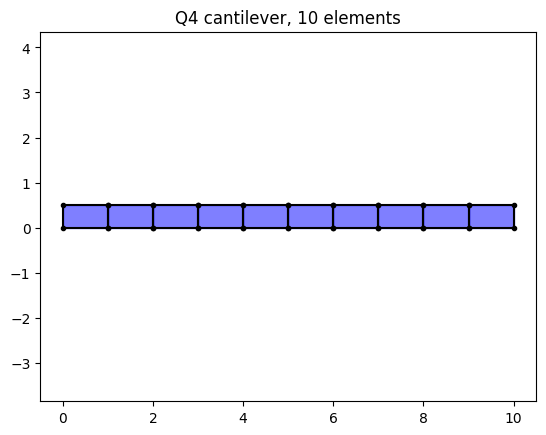

In [2]:
E, v, t, plane = 210000.0, 0.3, 1.0, 1
el_num, Length, Height, Load = 10, 10.0, 0.5, -25.0


def cantilever(ElementType, Length=Length, Height=Height):
    """Q4 and 5B come from Mesh, Q8 needs the eight node mesher."""
    Mesher = Q8Mesh if ElementType == 'Q8' else Mesh
    m = Mesher(E, v, t, plane, ElementType)
    m.SimpleBeam(el_num, Length, Height, Load)
    return m


ax = Plotting.InitialMesh(cantilever('Q4'))
ax.set_title('Q4 cantilever, 10 elements');

## Elements

- **Q4** four node quadrilateral
- **5B** five parameter assumed stress (Pian-Sumihara)
- **Q8** eight node quadrilateral

Linear tip deflection against beam theory. Q4 shear locks badly at this aspect
ratio; the other two do not.

In [3]:
I = t*Height**3/12
EulerBernoulli = Load*Length**3/(3*(E/(1 - v**2))*I)   # plane strain modulus, no shear

print(f"{'element':<10}{'tip uy':>12}{'/ beam theory':>16}")
for ElementType in ('Q4', '5B', 'Q8'):
    m = cantilever(ElementType)
    FEMSolvers.LinearSolver(m)
    print(f"{ElementType:<10}{m.U[-1, 0]:>12.5f}{m.U[-1, 0]/EulerBernoulli:>16.3f}")

print(f"\nEuler-Bernoulli reference: {EulerBernoulli:.5f}")

element         tip uy   / beam theory
Q4            -1.32361           0.382
5B            -3.46428           0.999
Q8            -3.46926           1.001

Euler-Bernoulli reference: -3.46667


## Solvers

- **Linear** one solve, small deformation
- **NonLinear** Newton with the load applied in steps
- **ArcLength** continuation, traces equilibrium paths past limit points

Each reports its convergence history to the `fem2d.solvers` logger:

In [4]:
m = cantilever('5B')
FEMSolvers.NonLinearSolver(m, LoadSteps=2, tol=1e-6)

Load step 1 of 2


  iteration 0, residual norm 1.000000e+00


  iteration 1, residual norm 3.107243e+03


  iteration 2, residual norm 1.182701e+02


  iteration 3, residual norm 2.492896e-01


...

  iteration 3, residual norm 4.913788e-01


  iteration 4, residual norm 5.014091e+00


  iteration 5, residual norm 2.189165e-03


  iteration 6, residual norm 1.107633e-04


  iteration 7, residual norm 1.409709e-11


### All nine combinations

The arc length solver stops at a fixed accumulated arc length rather than a
fixed load, so each element reaches a different load factor: the artificially
stiff Q4 travels much further in load for the same arc length.

In [5]:
Solvers = {
    'Linear':    lambda m: FEMSolvers.LinearSolver(m),
    'NonLinear': lambda m: FEMSolvers.NonLinearSolver(m, LoadSteps=3, tol=1e-6),
    'ArcLength': lambda m: FEMSolvers.ArcLengthSolver(m, ArcLength=1.0, TotalArcLength=3.0, tol=1e-7),
}

Results = {}
print(f"{'element':<9}{'solver':<12}{'tip uy':>11}{'load factor':>13}{'steps':>7}")
for ElementType in ('Q4', '5B', 'Q8'):
    for name, run in Solvers.items():
        m = cantilever(ElementType)
        with quiet():
            run(m)
        Results[ElementType, name] = m
        LoadFactor = 1.0 if name == 'Linear' else m.LoadValues[-1]
        Steps = '-' if name == 'Linear' else str(m.AllU.shape[1] - 1)
        print(f"{ElementType:<9}{name:<12}{m.U[-1, 0]:>11.5f}{LoadFactor:>13.4f}{Steps:>7}")

element  solver           tip uy  load factor  steps
Q4       Linear         -1.32361       1.0000      -


Q4       NonLinear      -1.31473       1.0000      3


Q4       ArcLength      -1.24749       0.9477      3
5B       Linear         -3.46428       1.0000      -


5B       NonLinear      -3.18954       1.0000      3


5B       ArcLength      -1.24797       0.3623      3
Q8       Linear         -3.46926       1.0000      -


Q8       NonLinear      -3.19380       1.0000      3


Q8       ArcLength      -0.82126       0.2367      3


## Deformed shapes

`Overlay` draws the undeformed mesh under the deformed one; `steps` fades in the
intermediate load steps.

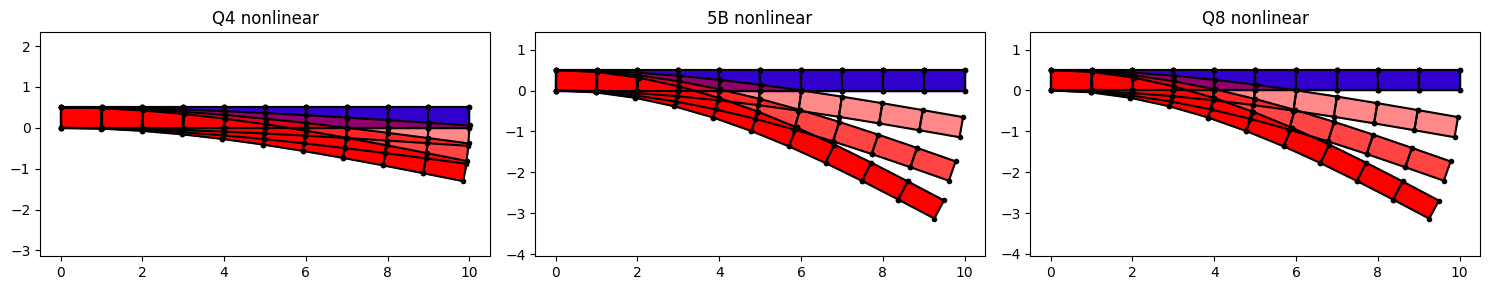

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.0))
for ax, ElementType in zip(axes, ('Q4', '5B', 'Q8')):
    Plotting.Overlay(Results[ElementType, 'NonLinear'], ax=ax, steps=1)
    ax.set_title(f"{ElementType} nonlinear")
plt.tight_layout()

## Load paths

`LoadPath` plots the load factor against the displacement of the loaded node.

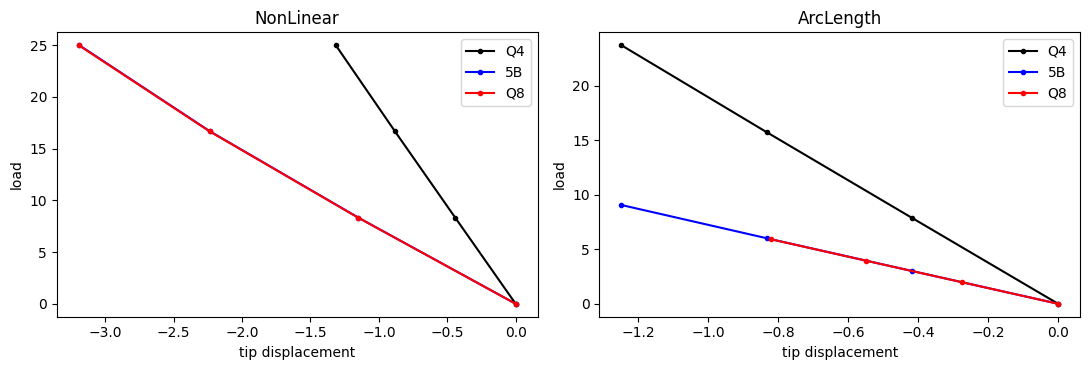

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, Solver in zip(axes, ('NonLinear', 'ArcLength')):
    for ElementType, colour in zip(('Q4', '5B', 'Q8'), ('k', 'b', 'r')):
        Plotting.LoadPath(Results[ElementType, Solver], ax=ax, c=colour)
    ax.set(xlabel='tip displacement', ylabel='load', title=Solver)
    ax.legend(['Q4', '5B', 'Q8'])
plt.tight_layout()

## Meshers

`SimpleBeam`, `SingleElement`, `LeeFrame` and `SemiCircularArch`. The eight node
`Q8Mesh` provides `SimpleBeam` and `SingleElement` only; its `SemiCircularArch`
raises `NotImplementedError`.

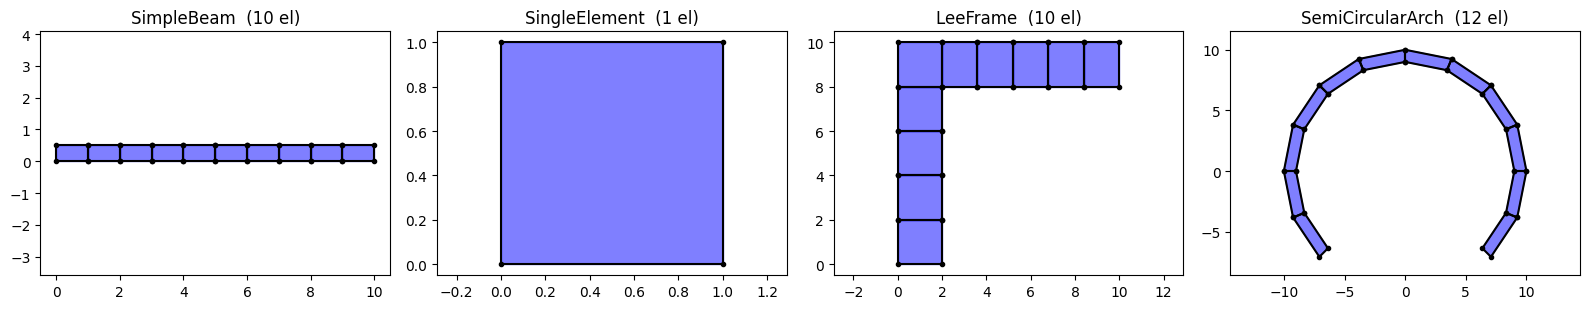

In [8]:
Meshers = {
    'SimpleBeam':       lambda m: m.SimpleBeam(10, 10.0, 0.5, Load),
    'SingleElement':    lambda m: m.SingleElement(1.0, 1.0, Load),
    'LeeFrame':         lambda m: m.LeeFrame(10, [10.0, 10.0], Load),
    'SemiCircularArch': lambda m: m.SemiCircularArch(12, 10.0, [10.0, 10.0], 1.0, Load),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
for ax, (name, build) in zip(axes, Meshers.items()):
    m = Mesh(E, v, t, plane, 'Q4')
    build(m)
    Plotting.InitialMesh(m, ax=ax)
    ax.set_title(f"{name}  ({m.Elements.shape[0]} el)")
plt.tight_layout()

## Stress and strain contours

`StressContour` and `StrainContour` draw a field on the deformed or undeformed
mesh. Settings live in a `ContourOptions` dataclass, so one styled set can be
reused across a figure.

Stress and strain are discontinuous between elements, and `Recovery` chooses what
happens at the nodes:

- **`'extrapolate'`** (default) samples at the Gauss points, where the stress is most
  accurate, fits back to the nodes and averages. This is what commercial codes do.
- **`'average'`** evaluates at the nodes and averages there. The usual textbook
  description, though nodes are the worst place to sample a stress.
- **`'none'`** does not average, so the jumps between elements stay visible. The most
  useful setting for judging whether a mesh is fine enough.

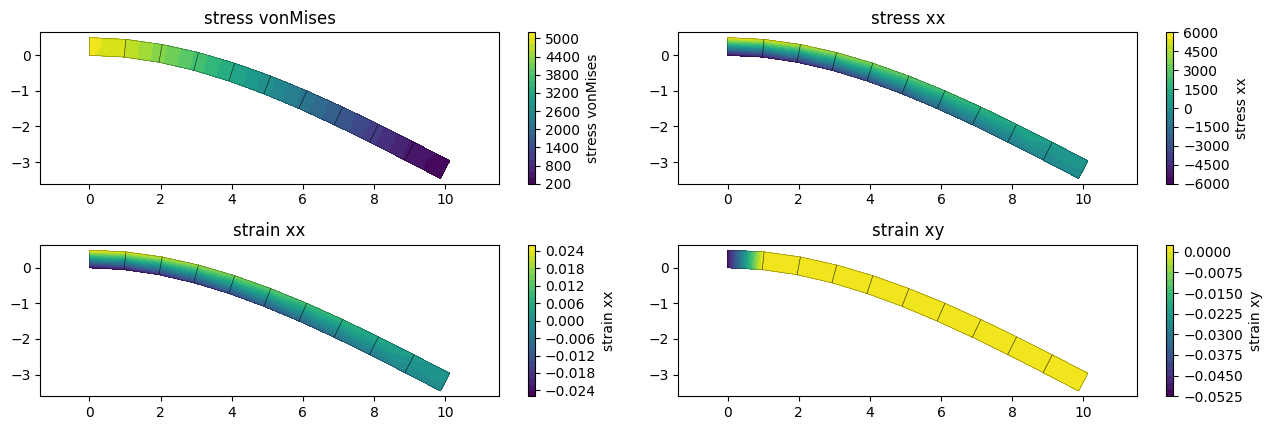

In [9]:
from dataclasses import replace

from fem2d.postprocessing import ContourOptions, NodalField

Beam = cantilever('5B')
with quiet():
    FEMSolvers.LinearSolver(Beam)

fig, axes = plt.subplots(2, 2, figsize=(13, 4.4))
Base = ContourOptions(Deformed=True, Scale=1.0, Levels=24)

for ax, (Kind, Component) in zip(axes.ravel(),
                                 [('stress', 'vonMises'), ('stress', 'xx'),
                                  ('strain', 'xx'), ('strain', 'xy')],
                                 strict=True):
    Draw = Plotting.StressContour if Kind == 'stress' else Plotting.StrainContour
    Draw(Beam, replace(Base, Component=Component, ax=ax))
    ax.set_title(f'{Kind} {Component}')

plt.tight_layout()

The recovery choice only shows up where the field is not exactly representable at the
nodes. On this regular mesh `'extrapolate'` and `'average'` agree to the last digit;
distort the mesh and they separate.

extrapolate  peak sxx =   5700.000
average      peak sxx =   5700.000


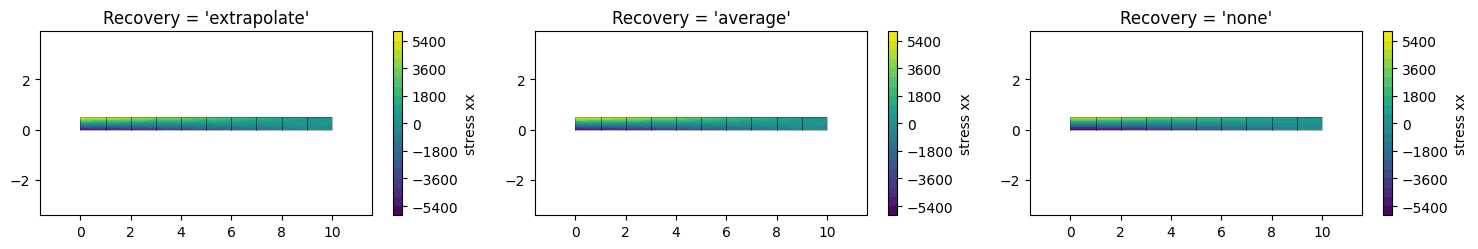

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 2.6))
for ax, Recovery in zip(axes, ('extrapolate', 'average', 'none'), strict=True):
    Plotting.StressContour(Beam, ContourOptions(Component='xx', Recovery=Recovery,
                                                Deformed=False, ax=ax))
    ax.set_title(f"Recovery = '{Recovery}'")
plt.tight_layout()

for Recovery in ('extrapolate', 'average'):
    Values, _, _ = NodalField(Beam, 'stress', 'xx', Recovery=Recovery)
    print(f"{Recovery:<12} peak sxx = {Values.max():10.3f}")

The five parameter element recovers its stress from its own assumed field rather than
from the displacements, which is what the element exists for. Transverse shear shows
why that matters.

For a rectangular section the exact shear is parabolic, $1.5 (V/A)$ at the neutral
axis and zero at both surfaces; $V/A = -25/0.5 = -50$ is only its **average**. The
mesh here is one element deep, so none of these elements resolve the parabola. What
they can be judged on is whether they recover the section average, and the assumed
stress field lands on it exactly: for a rectangle $a_1b_1 = a_3b_3 = 0$, so the shear
row of $P$ collapses to a single constant per element.

In [11]:
print('transverse shear through the depth at mid span')
print('section average V/A = -50.00')
print()

for ElementType in ('Q4', '5B', 'Q8'):
    m = cantilever(ElementType)
    with quiet():
        FEMSolvers.LinearSolver(m)

    Values, Coordinates, _ = NodalField(m, 'stress', 'xy')
    Mid = np.isclose(Coordinates[:, 0], 5.0, atol=0.3)
    Order = np.argsort(Coordinates[Mid, 1])

    print(f'{ElementType:<4} y   = {np.round(Coordinates[Mid, 1][Order], 3)}')
    print(f'     sxy = {np.round(Values[Mid][Order], 2)}')

print()
print('Q4 is nowhere near, which is shear locking seen directly.')
print('5B sits on the section average by construction.')

transverse shear through the depth at mid span
section average V/A = -50.00

Q4   y   = [0.  0.5]
     sxy = [30. 30.]
5B   y   = [0.  0.5]
     sxy = [-50. -50.]
Q8   y   = [0.   0.25 0.5 ]
     sxy = [ -99.47 -110.71  -99.47]

Q4 is nowhere near, which is shear locking seen directly.
5B sits on the section average by construction.


## Extending

`FEMSolvers` is a façade over solver classes, which can be used directly:

```python
LinearSolver(mesh, Sensitivity=True).Solve()
```

An element supplies only its geometry. Everything else, from the Jacobian
through to the tangent stiffness and the shape derivatives, comes from
`Element` and `ShapeDerivative`.

In [12]:
from fem2d.elements import Element, RegisterElement, RegisteredElements, ShapeDerivative
from fem2d.solvers import LinearSolver


class Quad4(Element):
    """A four node quadrilateral, written from scratch."""

    NumNodes = 4
    QuadOrder = 2

    def ShapeFunctions(self, xi, eta):
        return np.array([1/4 * (1 - xi)*(1 - eta), 1/4 * (1 + xi)*(1 - eta),
                         1/4 * (1 + xi)*(1 + eta), 1/4 * (1 - xi)*(1 + eta)])

    def ShapeDerivatives(self, xi, eta):
        return np.array([[-1/4 * (1 - eta), 1/4 * (1 - eta), 1/4 * (1 + eta), -1/4 * (1 + eta)],
                         [-1/4 * (1 - xi), -1/4 * (1 + xi), 1/4 * (1 + xi), 1/4 * (1 - xi)]])


class dQuad4dX(ShapeDerivative, Quad4):
    """Its shape derivatives; no body needed."""


RegisterElement('Quad4', Quad4, dQuad4dX)
print('registered elements:', RegisteredElements())

# It now behaves exactly like the built in Q4, sensitivities included.
Mine = cantilever('Quad4')
Built = cantilever('Q4')
with quiet():
    LinearSolver(Mine, Sensitivity=True).Solve()
    LinearSolver(Built, Sensitivity=True).Solve()

print(f"Quad4 tip {Mine.U[-1, 0]:.9f}   Q4 tip {Built.U[-1, 0]:.9f}")
print('identical:', np.array_equal(Mine.U, Built.U) and np.array_equal(Mine.dUdx, Built.dUdx))

registered elements: ['5B', 'Q4', 'Q8', 'Quad4']


Quad4 tip -1.323605702   Q4 tip -1.323605702
identical: True
